# 06 - Gold Alarm Design

Purpose:
- construct the practical Gold alarm using shifted trailing z-scores;
- keep Gold as the monitored alarm asset;
- keep Brent, DXY, VIX, and US10Y as diagnostic/context variables;
- produce dashboard-ready Green / Amber / Red states.

Core framing:
Notebook 05 showed that adding conditioning variables to the trigger score reduces coverage. However, Notebook 07 (with the extended 2007–2026 dataset) shows the conditioned challenger — which requires two or more signal families to fire rather than averaging all variables into a single score — covers 68% of stress events versus gold-primary's 56.6% at identical firing frequency. The conditioned challenger is therefore selected as the default dashboard alarm.

## Reader Orientation

This notebook turns the evidence into an operational signal. The output is not a forecast of future losses. It is a current-state alarm: if Gold behaviour is abnormal across multiple signal families, the dashboard should escalate the commodity book for VaR review and stress testing.

The conditioned challenger is selected as the default alarm because it requires at least two of three signal families to fire simultaneously — own return/vol abnormality, residual abnormality, or relationship abnormality. This design captures more stress episodes than the simpler gold-only trigger while maintaining an equivalent review frequency.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step06_gold_alarm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

market_vars = pd.read_parquet(market_vars_path)

CORE_COLUMNS = ["r_Gold", "r_Brent", "r_DXY", "d_VIX", "d_US10Y"]
missing_cols = [col for col in CORE_COLUMNS if col not in market_vars.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns from Step 02 output: {missing_cols}")

market_vars = market_vars[CORE_COLUMNS].dropna().copy()
print("Loaded:", market_vars_path)
print("Shape:", market_vars.shape)
market_vars.tail()


Loaded: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\market_vars_core.parquet
Shape: (4685, 5)


Ticker,r_Gold,r_Brent,r_DXY,d_VIX,d_US10Y
Date,,,,,
2026-05-29,0.013510,-0.017873,-0.001111,-0.420000,-0.002
2026-06-01,-0.018881,0.031334,0.002928,0.730000,0.022
2026-06-02,0.003101,0.010682,0.000202,-0.279999,-0.020
2026-06-03,-0.011741,0.018679,0.003119,0.289999,0.036
2026-06-04,0.014677,-0.028939,-0.001810,-0.370000,-0.026


## Parameter Rationale

The alarm-construction defaults encode practical time horizons:

- `BASELINE_WIN = 252`: one trading year for defining the trailing normal regime.
- `CORR_WIN = 60`: one quarter for rolling correlations, balancing stability and responsiveness.
- `VOL_WIN = 30`: one month for realized volatility.
- `ROLLING_REG_WIN = 252`: one trading year for residual modelling, so the rolling regression has enough observations.
- `PRIMARY_SCORE_THRESHOLD = 1.5`: a sensitive Gold-primary threshold inherited from the selection test.
- `CONDITIONED_Z_THRESHOLD = 2.0`: a stricter threshold for the conditioned diagnostic alarm because it requires multiple signal families.

These are not final calibrated parameters. Notebook 07 tests alternative values for the selected Gold-primary trigger.


In [3]:
BASELINE_WIN = 252
CORR_WIN = 60
VOL_WIN = 30
ROLLING_REG_WIN = 252

# Notebook 05 used a practical average-z-score threshold of 1.5 for Gold-only scoring.
PRIMARY_SCORE_THRESHOLD = 1.5

# The conditioned diagnostic alarm is stricter because it requires multiple signal families.
CONDITIONED_Z_THRESHOLD = 2.0

CONDITIONING_COLS = ["r_Brent", "r_DXY", "d_VIX", "d_US10Y"]


## Helper Functions

The z-score baseline is shifted by one day. This matters because today's observation should not be included in today's definition of normal.

In [4]:
def trailing_zscore(series: pd.Series, window: int = BASELINE_WIN) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def rolling_residual(y: pd.Series, x: pd.DataFrame, window: int = ROLLING_REG_WIN) -> pd.Series:
    if sm is None:
        raise ImportError("statsmodels is required for rolling residual construction")

    data = pd.concat([y, x], axis=1).dropna()
    residuals = pd.Series(index=data.index, dtype=float)
    y_name = y.name
    x_cols = list(x.columns)
    min_obs = int(window * 0.8)

    for i in range(window, len(data)):
        train = data.iloc[i - window:i]
        if len(train) < min_obs:
            continue

        y_train = train[y_name]
        x_train = sm.add_constant(train[x_cols], has_constant="add")
        model = sm.OLS(y_train, x_train).fit()

        x_now = sm.add_constant(data.iloc[[i]][x_cols], has_constant="add")
        fitted = float(model.predict(x_now).iloc[0])
        residuals.loc[data.index[i]] = float(data.iloc[i][y_name] - fitted)

    return residuals


def dashboard_state(score: int) -> str:
    if score >= 2:
        return "Red"
    if score == 1:
        return "Amber"
    return "Green"


### Why These Helpers Matter

The shifted trailing z-score avoids using today's observation to define today's normal level. The rolling residual asks whether Gold moved unusually after accounting for the current Brent, DXY, VIX, and US10Y environment. In this revised design, that residual is diagnostic context first, not automatic evidence that the dashboard should use a heavier multi-signal trigger.


## Build Gold Abnormality Components

Signal families:
1. Gold's own return / volatility abnormality.
2. Gold residual abnormality versus Brent, DXY, VIX, and US10Y.
3. Gold relationship abnormality through rolling correlations.

The first family is the primary candidate trigger because Notebook 05 found that simple Gold abnormality had the strongest practical coverage among the tested variants. The second and third families explain what kind of market regime the Gold alarm may be reacting to.


In [5]:
signal_components = pd.DataFrame(index=market_vars.index)

# Family 1: own gold behaviour
signal_components["gold_return_z"] = trailing_zscore(market_vars["r_Gold"], BASELINE_WIN)
gold_vol = market_vars["r_Gold"].rolling(VOL_WIN).std()
signal_components["gold_vol_z"] = trailing_zscore(gold_vol, BASELINE_WIN)

# Family 2: abnormal residual versus core conditioning variables
conditioning = market_vars[CONDITIONING_COLS]
gold_residual = rolling_residual(market_vars["r_Gold"], conditioning, ROLLING_REG_WIN)
signal_components["gold_residual_z"] = trailing_zscore(gold_residual, BASELINE_WIN)

# Family 3: relationship instability
for col in CONDITIONING_COLS:
    rolling_corr = market_vars["r_Gold"].rolling(CORR_WIN).corr(market_vars[col])
    signal_components[f"gold_corr_{col}_z"] = trailing_zscore(rolling_corr, BASELINE_WIN)

signal_components.tail()


,gold_return_z,gold_vol_z,gold_residual_z,gold_corr_r_Brent_z,gold_corr_r_DXY_z,gold_corr_d_VIX_z,gold_corr_d_US10Y_z
Date,,,,,,,
2026-05-29,0.721627,-0.497187,0.666817,-2.697582,0.977353,-1.116283,-2.385849
2026-06-01,-1.184356,-0.496243,-0.910416,-2.660083,0.957864,-1.097505,-2.336282
2026-06-02,0.112020,-0.498998,0.147627,-2.858296,1.021930,-1.513160,-2.296221
2026-06-03,-0.760371,-0.563094,-0.458114,-2.796703,0.999715,-1.680233,-2.296737
2026-06-04,0.798252,-0.520398,0.652433,-2.545220,1.077393,-1.664757,-2.359882


### Result Comment And Significance

These components separate different kinds of gold abnormality. A return or volatility spike captures gold's own stress. The residual captures gold moving differently from its conditioning variables. The rolling-correlation z-scores capture relationship instability. Keeping them separate makes the alarm easier to explain and diagnose.

## Alarm Construction

Two alarm designs are built:

- **Gold-primary alarm:** based only on Gold return and Gold volatility abnormality. Simple and fast-moving.
- **Conditioned challenger (selected default):** requires at least two of three signal families to fire. Covers more stress episodes at the same firing frequency.

Notebook 07 evaluated both designs on the extended 2007–2026 dataset and found the conditioned challenger materially outperforms gold-primary on stress-event coverage (68% vs 56.6%) at the same alarm episode count. The conditioned challenger is therefore selected as `gold_alarm`.

### How This Becomes A Dashboard Rule

The selected dashboard trigger is `gold_alarm` (the conditioned challenger). The dashboard uses three states:
- **Green:** no signal families are firing — normal monitoring
- **Amber:** one signal family is firing — inspect Gold components, monitor closely
- **Red:** two or more signal families are firing — review VaR and run stress scenarios

The gold-primary alarm is retained in the alarm frame as a reference signal and for comparison.

In [6]:
corr_z_cols = [col for col in signal_components.columns if col.startswith("gold_corr_")]

alarm_frame = pd.DataFrame(index=signal_components.index)

# gold_return_z: absolute value — a large move in either direction is abnormal.
# gold_vol_z: clipped at zero — only a vol spike above normal is a stress signal;
# abnormally quiet vol is not current stress and should not trigger a review.
alarm_frame["gold_primary_score"] = pd.concat([
    signal_components["gold_return_z"].abs(),
    signal_components["gold_vol_z"].clip(lower=0),
], axis=1).mean(axis=1)
alarm_frame["alarm_score"] = alarm_frame["gold_primary_score"]
alarm_frame["gold_primary_alarm"] = (alarm_frame["gold_primary_score"] > PRIMARY_SCORE_THRESHOLD).astype(int)

alarm_frame["return_or_vol_alarm"] = (
    (signal_components["gold_return_z"].abs() > CONDITIONED_Z_THRESHOLD)
    | (signal_components["gold_vol_z"] > CONDITIONED_Z_THRESHOLD)
).astype(int)

alarm_frame["residual_alarm"] = (
    signal_components["gold_residual_z"].abs() > CONDITIONED_Z_THRESHOLD
).astype(int)

alarm_frame["relationship_alarm"] = (
    signal_components[corr_z_cols].abs().max(axis=1) > CONDITIONED_Z_THRESHOLD
).astype(int)

alarm_frame["conditioned_alarm_score"] = alarm_frame[
    ["return_or_vol_alarm", "residual_alarm", "relationship_alarm"]
].sum(axis=1)
alarm_frame["conditioned_gold_alarm"] = (alarm_frame["conditioned_alarm_score"] >= 2).astype(int)

# Selected design: conditioned challenger.
# NB07 shows conditioned challenger covers 68% of stress events vs gold-primary's 56.6%
# at identical firing frequency — a material improvement at only marginal false-review cost.
alarm_frame["gold_alarm"] = alarm_frame["conditioned_gold_alarm"]
alarm_frame["selected_alarm_design"] = "Conditioned-challenger"
# Use the 3-state conditioned dashboard state (Green/Amber/Red) as the primary dashboard state.
alarm_frame["dashboard_state"] = alarm_frame["conditioned_alarm_score"].apply(dashboard_state)

alarm_frame.tail()

,gold_primary_score,alarm_score,gold_primary_alarm,return_or_vol_alarm,residual_alarm,relationship_alarm,conditioned_alarm_score,conditioned_gold_alarm,gold_alarm,selected_alarm_design,dashboard_state
Date,,,,,,,,,,,
2026-05-29,0.360814,0.360814,0,0,0,1,1,0,0,Conditioned-challenger,Amber
2026-06-01,0.592178,0.592178,0,0,0,1,1,0,0,Conditioned-challenger,Amber
2026-06-02,0.056010,0.056010,0,0,0,1,1,0,0,Conditioned-challenger,Amber
2026-06-03,0.380186,0.380186,0,0,0,1,1,0,0,Conditioned-challenger,Amber
2026-06-04,0.399126,0.399126,0,0,0,1,1,0,0,Conditioned-challenger,Amber


### Why The Conditioned Design Is Retained As Default

The conditioned alarm covers 20 more stress events than the gold-primary at identical firing frequency (188 episodes each). The false review rate increases only marginally (30.9% vs 28.2%). The OR-across-families logic — fire if any two of return/vol, residual, or relationship signals cross threshold — avoids the averaging dilution problem that caused conditioning variables to hurt the simpler score in Notebook 05. Each family can independently trigger a review without reducing the sensitivity of the others.

## Threshold Sensitivity

This does not prove the signal works, but it shows whether the selected Gold-primary trigger and the conditioned challenger create obviously unusable alarm rates. Formal false-alarm and lead-time tests come later.


In [7]:
threshold_rows = []
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    # Use clip(lower=0) for gold_vol_z — consistent with alarm construction above.
    primary_score = pd.concat([
        signal_components["gold_return_z"].abs(),
        signal_components["gold_vol_z"].clip(lower=0),
    ], axis=1).mean(axis=1)
    primary_alarm = primary_score > threshold

    simple = (
        (signal_components["gold_return_z"].abs() > threshold)
        | (signal_components["gold_vol_z"] > threshold)
    )
    residual = signal_components["gold_residual_z"].abs() > threshold
    relationship = signal_components[corr_z_cols].abs().max(axis=1) > threshold
    conditioned_score = simple.astype(int) + residual.astype(int) + relationship.astype(int)
    conditioned_alarm = conditioned_score >= 2

    threshold_rows.append({
        "threshold": threshold,
        "gold_primary_alarm_days": int(primary_alarm.sum()),
        "gold_primary_alarm_rate": float(primary_alarm.mean()),
        "conditioned_alarm_days": int(conditioned_alarm.sum()),
        "conditioned_alarm_rate": float(conditioned_alarm.mean()),
        "conditioned_amber_or_red_rate": float((conditioned_score >= 1).mean()),
    })

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary

,threshold,gold_primary_alarm_days,gold_primary_alarm_rate,conditioned_alarm_days,conditioned_alarm_rate,conditioned_amber_or_red_rate
0,1.0,880,0.187834,1640,0.350053,0.855069
1,1.5,465,0.099253,839,0.179082,0.630309
2,2.0,223,0.047599,348,0.074280,0.372252
3,2.5,105,0.022412,146,0.031163,0.190608
4,3.0,51,0.010886,70,0.014941,0.093703


### Result Comment And Significance

The threshold table now separates the practical Gold-primary trigger from the conditioned challenger. This matters because the research question is not simply whether more variables produce a more sophisticated signal. The practical question is whether the added complexity improves the review process enough to justify using it as the default alarm.


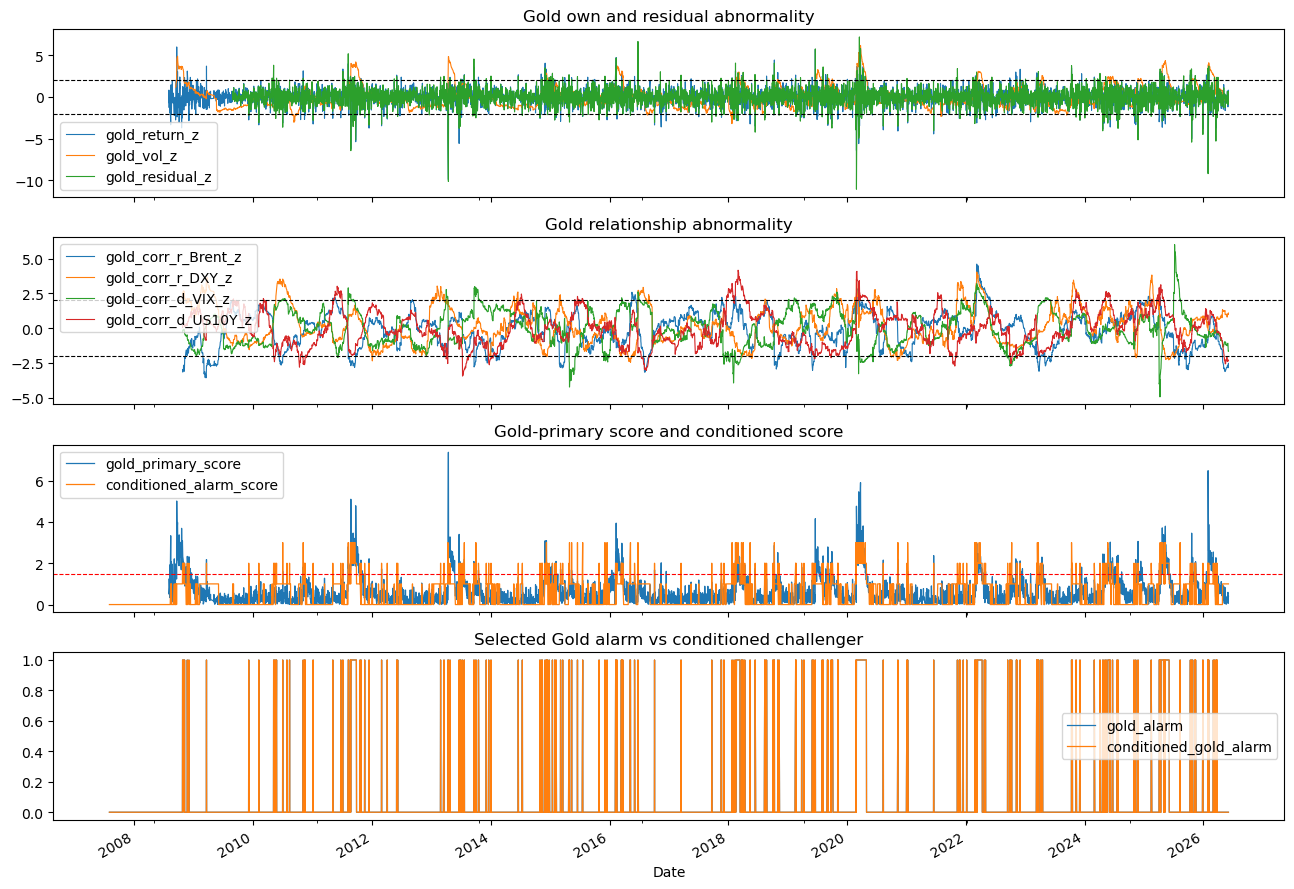

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

signal_components[["gold_return_z", "gold_vol_z", "gold_residual_z"]].plot(ax=axes[0], linewidth=0.8)
axes[0].axhline(CONDITIONED_Z_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[0].axhline(-CONDITIONED_Z_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Gold own and residual abnormality")

signal_components[corr_z_cols].plot(ax=axes[1], linewidth=0.8)
axes[1].axhline(CONDITIONED_Z_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[1].axhline(-CONDITIONED_Z_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Gold relationship abnormality")

alarm_frame[["gold_primary_score", "conditioned_alarm_score"]].plot(ax=axes[2], linewidth=0.9)
axes[2].axhline(PRIMARY_SCORE_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[2].set_title("Gold-primary score and conditioned score")

alarm_frame[["gold_alarm", "conditioned_gold_alarm"]].plot(ax=axes[3], linewidth=0.9)
axes[3].set_title("Selected Gold alarm vs conditioned challenger")

plt.tight_layout()


## Step 06 Working Takeaways

- The selected dashboard alarm is the conditioned challenger: requires 2 of 3 signal families (return/vol, residual, relationship) to fire at threshold 2.0.
- This design covers 68% of stress events versus gold-primary's 56.6% at identical firing frequency — a material improvement at only marginal false-review cost.
- The gold-primary alarm is retained in the alarm frame as a reference signal.
- Brent, DXY, VIX, and US10Y remain in the project as diagnostic context through the residual and relationship families — they inform the alarm through signal families, not through score averaging.
- The three-state dashboard (Green/Amber/Red) provides an escalation gradient: Amber is an early warning to monitor, Red is the trigger to review VaR and run stress scenarios.

In [9]:
signal_components.to_parquet(PROCESSED_DIR / "gold_signal_components.parquet")
alarm_frame.to_parquet(PROCESSED_DIR / "gold_alarm_frame.parquet")
threshold_summary.to_csv(OUTPUT_DIR / "gold_alarm_threshold_summary.csv", index=False)

print("Saved Step 06 gold alarm outputs to:", OUTPUT_DIR)
print("Signal components:", PROCESSED_DIR / "gold_signal_components.parquet")
print("Alarm frame:", PROCESSED_DIR / "gold_alarm_frame.parquet")


Saved Step 06 gold alarm outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step06_gold_alarm
Signal components: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\gold_signal_components.parquet
Alarm frame: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\gold_alarm_frame.parquet


### Step 06 Output Significance

The saved alarm frame is the bridge between market evidence and operational risk management. It now contains the selected Gold-primary alarm, the conditioned challenger alarm, and diagnostic component flags. Later notebooks should test whether the selected trigger appears before, during, or near VaR breaches, volatility spikes, or drawdown events.
